# CRAPome contaminant connectivity in PPI networks

Looks at whether proteins listed in the CRAPome AP-MS contaminant repository (`data/reprint-apms.org.tsv`) tend to have higher degree (connectivity) in a PPI network than proteins not listed in CRAPome. Highly-studied "hub" proteins are both more likely to be flagged as frequent background binders in AP-MS experiments and more likely to accumulate spurious interaction evidence in PPI databases (study bias, see Blumenthal et al., eLife 2024), so a positive association is expected.

Every analysis in this notebook is run on both PPI networks, gene-symbol node names:
- **IID** (`iid.human.Symbol.gt`)
- **STRING (min900)** (`string.human_links_v12_0_min900.Symbol.gt`, STRING v12.0, score > 0.9)

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path
from IPython.display import display
from graph_tool.all import load_graph

CRAPOME_PATH = "data/reprint-apms.org.tsv"

NETWORKS = {
    "IID": "/Users/motan/Uni/ba/data/alzheimer_symbol_runs/alzheimer_run_symbol_threshold_0.1/input/networks/iid.human.Symbol.gt",
    "STRING (min900)": "/Users/motan/Uni/ba/data/alzheimer_symbol_runs/alzheimer_run_symbol_threshold_0.1/input/networks/string.human_links_v12_0_min900.Symbol.gt",
}

sns.set_theme(style="whitegrid", rc={
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "legend.title_fontsize": 13,
})

## Load the CRAPome table

Each row is a protein; `CC1`...`CC412` are individual control (AP-MS background) experiments, and the value is the spectral count observed for that protein in that experiment. We derive, per protein:
- `n_experiments_detected`: number of control experiments with a non-zero count
- `experiment_frequency`: fraction of all control experiments the protein was detected in
- `total_spectral_count`: summed spectral counts across all experiments

In [10]:
crapome = pd.read_csv(CRAPOME_PATH, sep="\t")
cc_cols = [c for c in crapome.columns if c.startswith("CC")]

n_experiments_detected = (crapome[cc_cols] > 0).sum(axis=1)
crapome = pd.concat([
    crapome[["Uniprot ID"]],
    n_experiments_detected.rename("n_experiments_detected"),
    (n_experiments_detected / len(cc_cols)).rename("experiment_frequency"),
    crapome[cc_cols].sum(axis=1).rename("total_spectral_count"),
], axis=1)

crapome_summary = crapome.dropna(subset=["Uniprot ID"])

# Map UniProt accessions to gene symbols (the network node names) via the UniProt
# ID mapping file. A CRAPome row can list several semicolon-separated accessions
# (isoforms/paralogs), so explode before mapping.
uniprot_to_symbol = pd.read_csv(
    "data/HUMAN_9606_idmapping.dat",
    sep="\t",
    header=None,
    names=["uniprot", "id_type", "id_value"],
    usecols=[0, 1, 2],
)
uniprot_to_symbol = (
    uniprot_to_symbol[uniprot_to_symbol["id_type"] == "Gene_Name"][["uniprot", "id_value"]]
    .rename(columns={"id_value": "geneSymbol"})
    .drop_duplicates("uniprot")
)

crapome_summary = (
    crapome_summary
    .assign(**{"Uniprot ID": crapome_summary["Uniprot ID"].str.split(";")})
    .explode("Uniprot ID")
    .merge(uniprot_to_symbol, left_on="Uniprot ID", right_on="uniprot", how="left")
    .drop(columns="uniprot")
)

n_unmapped = crapome_summary["geneSymbol"].isna().sum()
crapome_summary = crapome_summary.dropna(subset=["geneSymbol"])

print(f"{len(cc_cols)} control experiments")
print(f"{len(crapome_summary)} CRAPome protein rows with a mapped gene symbol ({n_unmapped} UniProt accessions unmapped)")
print(f"{(crapome_summary['n_experiments_detected'] == 0).sum()} proteins detected in 0 control experiments")
crapome_summary.sort_values("n_experiments_detected", ascending=False).head()

343 control experiments
7823 CRAPome protein rows with a mapped gene symbol (1257 UniProt accessions unmapped)
0 proteins detected in 0 control experiments


,Uniprot ID,n_experiments_detected,experiment_frequency,total_spectral_count,geneSymbol
3269,P11142,328,0.956268,10381,HSPA8
3263,P34931,322,0.938776,5926,HSPA1L
7283,P68363,321,0.935860,10216,TUBA1B
7282,Q71U36,321,0.935860,9337,TUBA1A
7284,Q9BQE3,321,0.935860,9600,TUBA1C


In [39]:
detected_in_90_percent = crapome_summary[crapome_summary['experiment_frequency'] > 0.9].count()
#print(detected_in_90_percent)
detected_in_50_percent = crapome_summary[crapome_summary['experiment_frequency'] > 0.5].count()
print(detected_in_50_percent)
less_then_10 = crapome_summary[crapome_summary['experiment_frequency'] < 0.1].count()
more_than_x = crapome_summary[crapome['n_experiments_detected'] > 100].count()
print(more_than_x)

Uniprot ID                109
n_experiments_detected    109
experiment_frequency      109
total_spectral_count      109
geneSymbol                109
dtype: int64
Uniprot ID                320
n_experiments_detected    320
experiment_frequency      320
total_spectral_count      320
geneSymbol                320
dtype: int64


/var/folders/c3/7nxlprcs7lz9sl8c6_mdhy2w0000gn/T/ipykernel_78983/3804472437.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  more_than_x = crapome_summary[crapome['n_experiments_detected'] > 100].count()


### CRAPome distributions

Before linking to the network, look at how contamination "severity" is distributed across the 8,861 CRAPome proteins on its own: total spectral count (abundance, summed across all control experiments) and `n_experiments_detected` (how many of the 343 control experiments each protein turned up in).

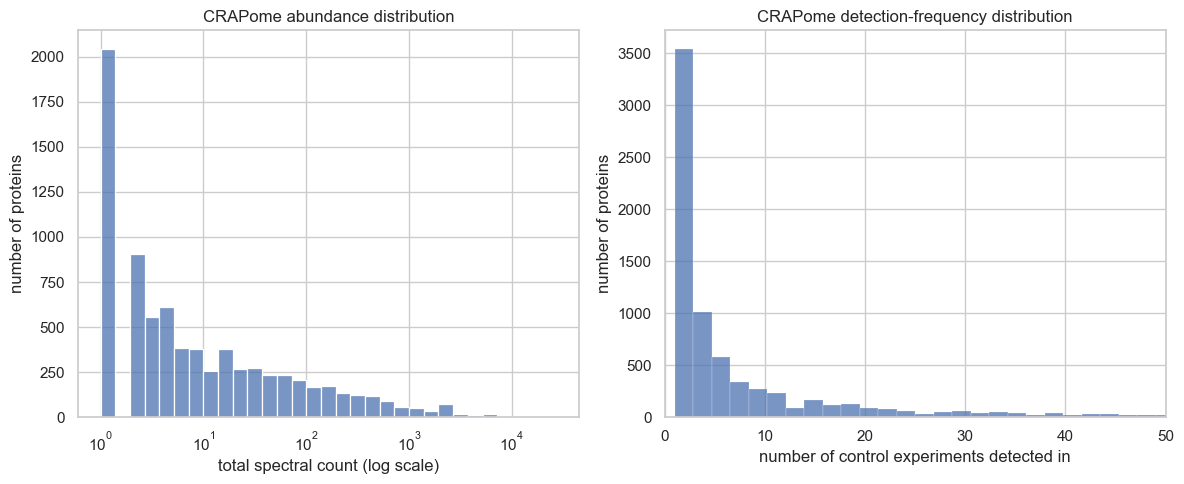

,total_spectral_count,n_experiments_detected
count,7823.000000,7823.000000
mean,134.513358,16.181133
std,769.914003,37.173717
min,1.000000,1.000000
25%,1.000000,1.000000
50%,5.000000,3.000000
75%,29.000000,12.000000
max,26876.000000,328.000000


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(
    data=crapome_summary[crapome_summary["total_spectral_count"] > 0],
    x="total_spectral_count",
    bins='auto',
    log_scale=True,
    ax=axes[0],
)
axes[0].set_xlabel("total spectral count (log scale)")
axes[0].set_ylabel("number of proteins")
axes[0].set_title("CRAPome abundance distribution")

sns.histplot(
    data=crapome_summary,
    x="n_experiments_detected",
    bins='auto',
    #log_scale=True,
    ax=axes[1],
)
axes[1].set_xlabel("number of control experiments detected in")
axes[1].set_ylabel("number of proteins")
axes[1].set_title("CRAPome detection-frequency distribution")
axes[1].set_xlim(0, 50)
fig.tight_layout()
plt.show()

crapome_summary[["total_spectral_count", "n_experiments_detected"]].describe()

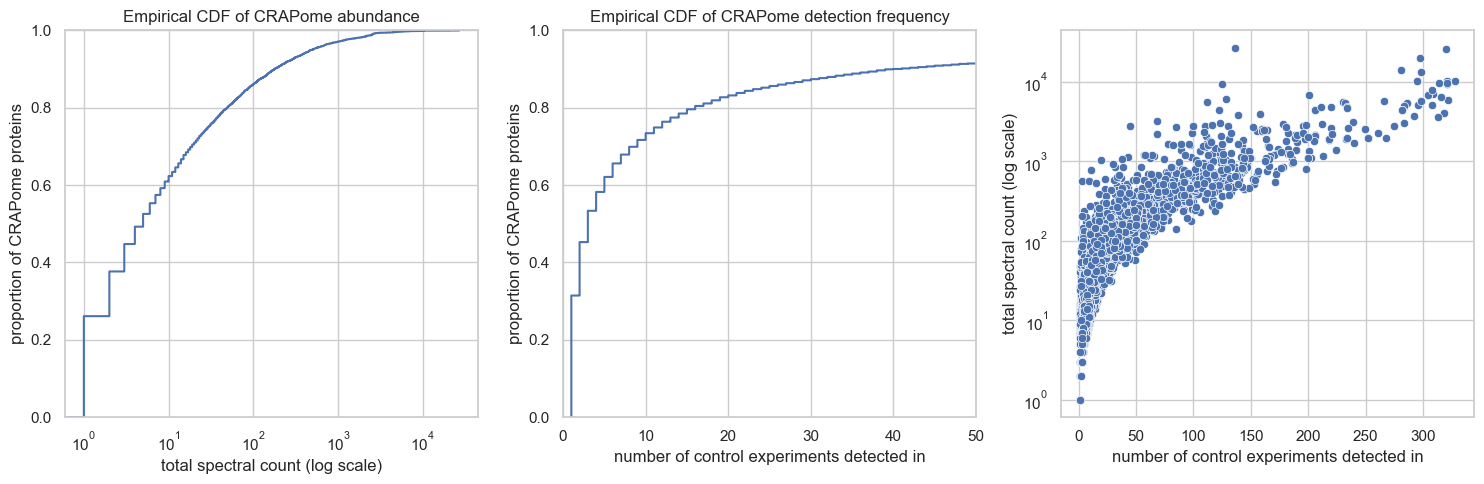

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.ecdfplot(
    data=crapome_summary[crapome_summary["total_spectral_count"] > 0],
    x="total_spectral_count",
    ax=axes[0],
)
axes[0].set_xscale("log")
axes[0].set_xlabel("total spectral count (log scale)")
axes[0].set_ylabel("proportion of CRAPome proteins")
axes[0].set_title("Empirical CDF of CRAPome abundance")

sns.ecdfplot(data=crapome_summary, x="n_experiments_detected", ax=axes[1])
axes[1].set_xlim(0, 50)
axes[1].set_xlabel("number of control experiments detected in")
axes[1].set_ylabel("proportion of CRAPome proteins")
axes[1].set_title("Empirical CDF of CRAPome detection frequency")

sns.scatterplot(data=crapome_summary, x="n_experiments_detected", y = "total_spectral_count")
axes[2].set_yscale("log")
axes[2].set_xlabel("number of control experiments detected in")
axes[2].set_ylabel("total spectral count (log scale)")

fig.tight_layout()
plt.show()

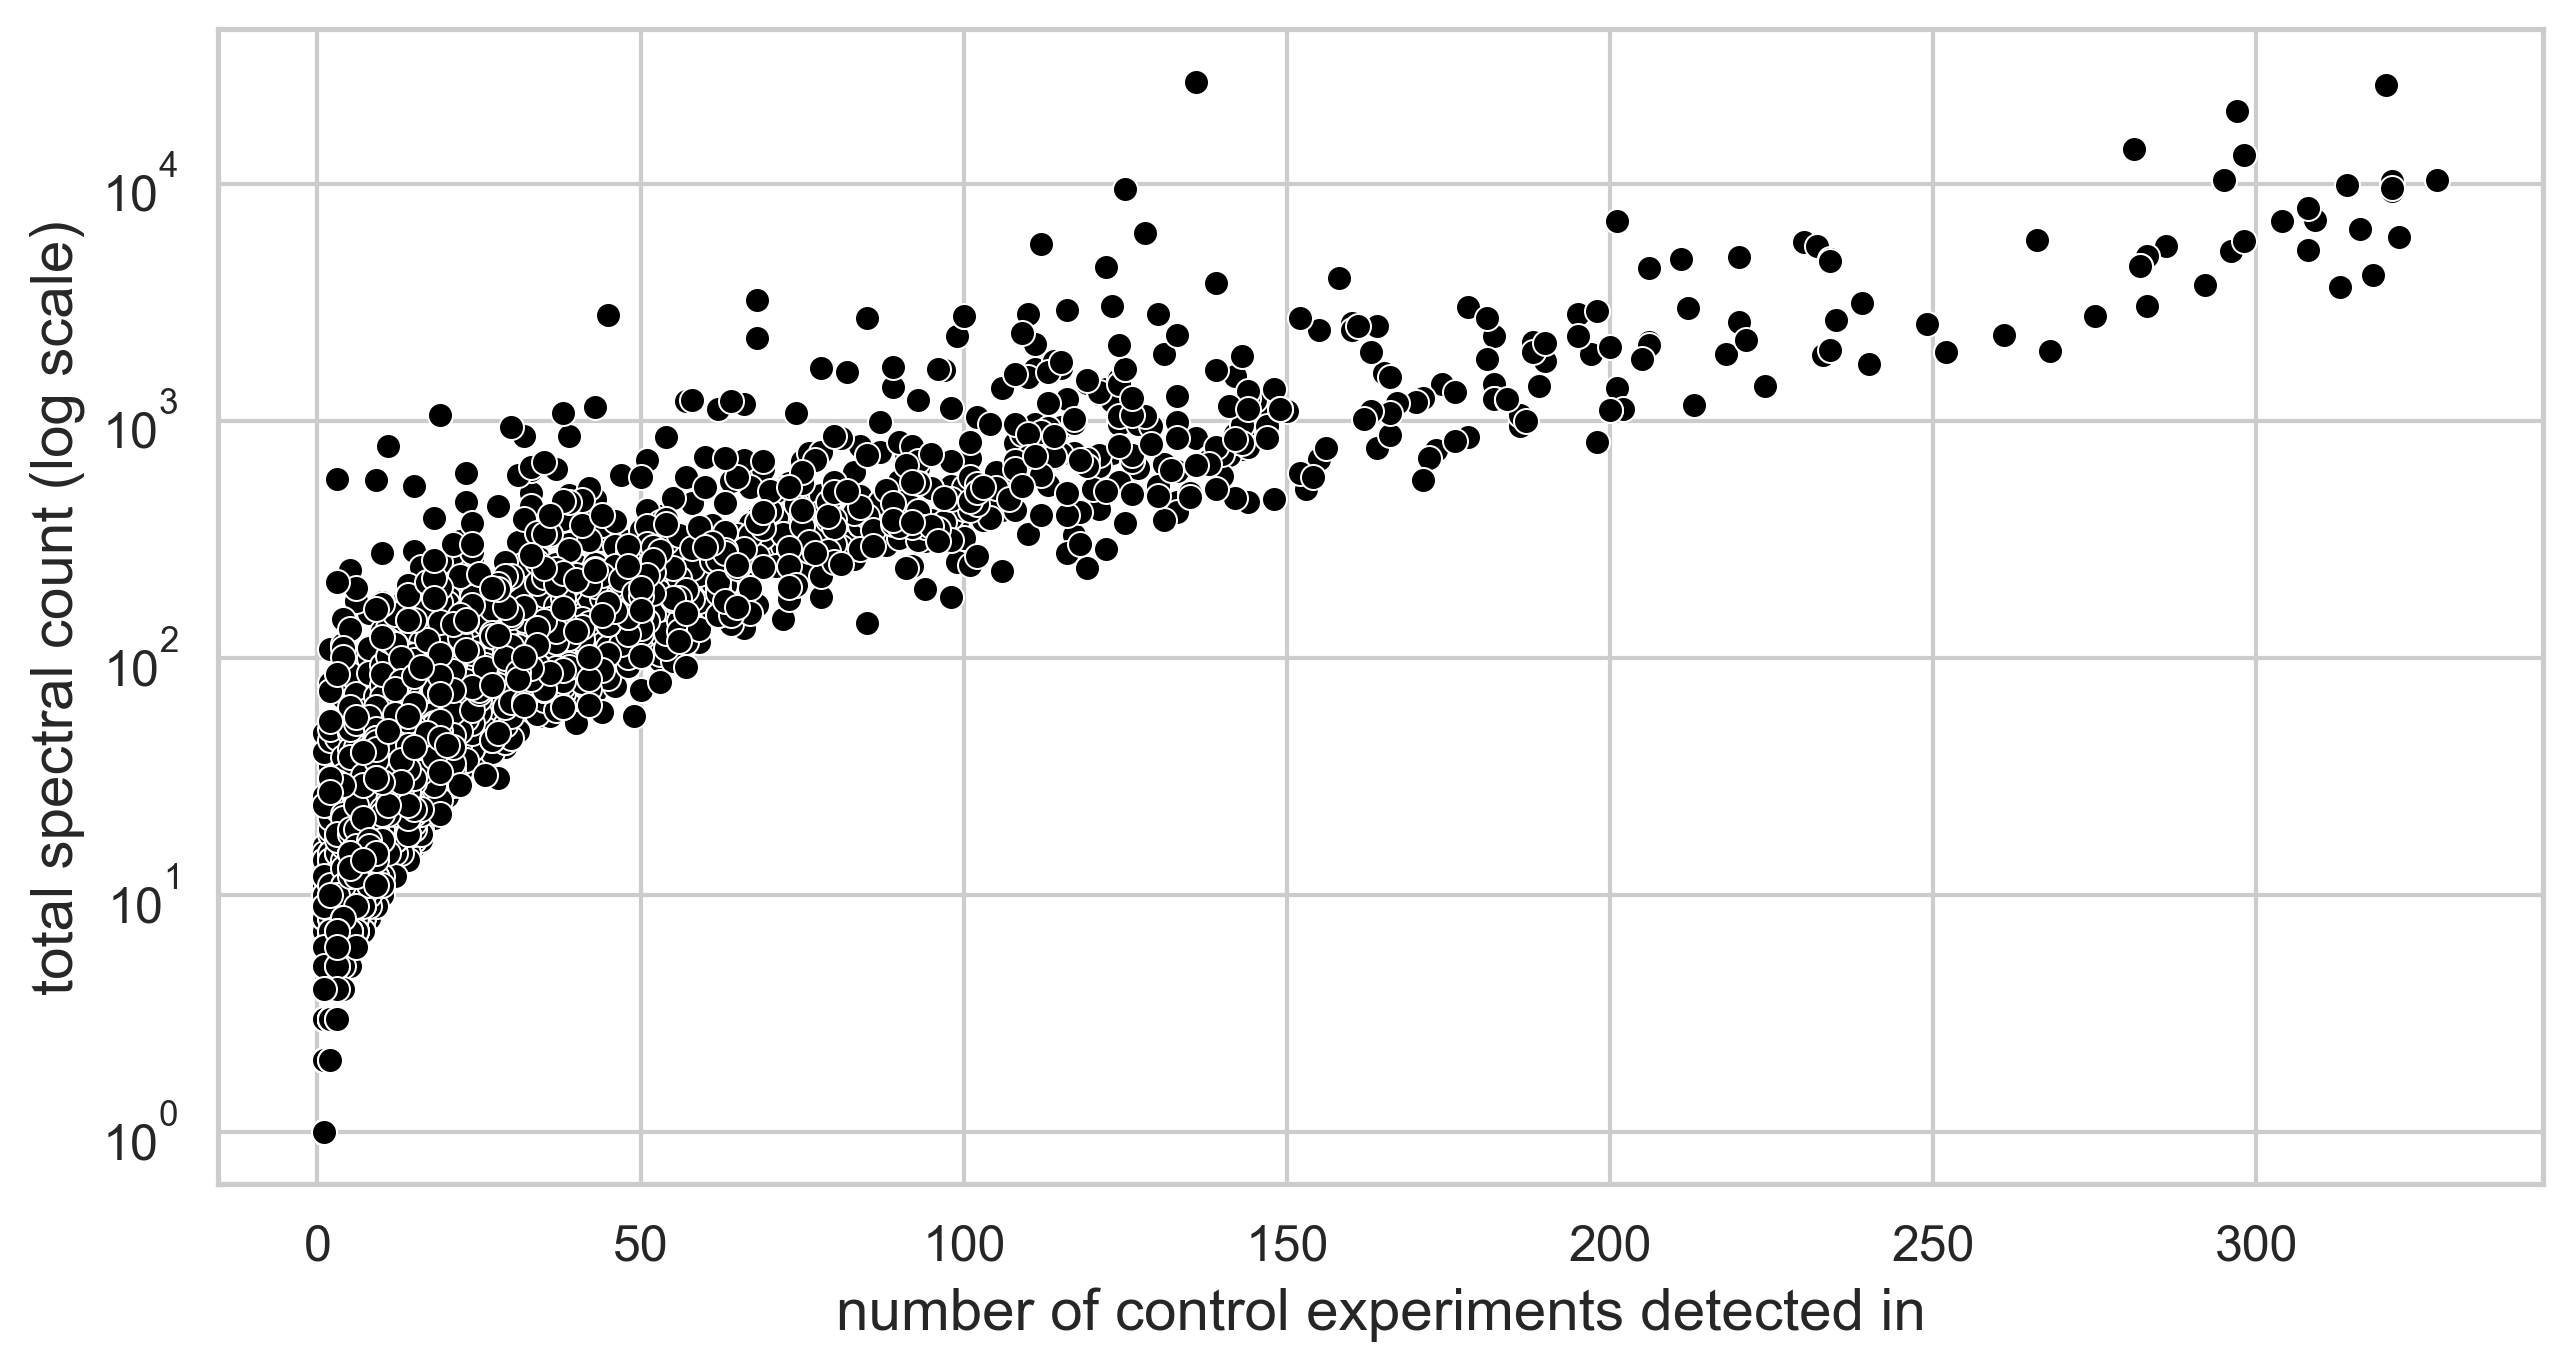

In [33]:

fig, ax = plt.subplots(figsize=(10, 5), dpi=300)
sns.scatterplot(data=crapome_summary, x="n_experiments_detected", y="total_spectral_count", ax=ax, color="#000000")
ax.set_yscale("log")
ax.set_xlabel("number of control experiments detected in")
ax.set_ylabel("total spectral count (log scale)")

plt.show()

## Load the networks and compute node degree

In [15]:
def load_degree_df(path):
    g = load_graph(str(path))
    degree_df = pd.DataFrame({
        "geneSymbol": [g.vp["name"][v] for v in g.vertices()],
        "degree": g.get_total_degrees(g.get_vertices()),
    })
    return g, degree_df

graphs = {}
degree_dfs = {}
for net_name, net_path in NETWORKS.items():
    g, degree_df = load_degree_df(net_path)
    graphs[net_name] = g
    degree_dfs[net_name] = degree_df
    print(f"{net_name}: {g}")

degree_dfs["IID"].head()

IID: <Graph object, undirected, with 18329 vertices and 1222211 edges, 1 internal vertex property, at 0x30c310690>
STRING (min900): <Graph object, undirected, with 11927 vertices and 97588 edges, 1 internal vertex property, at 0x30beaa190>


,geneSymbol,degree
0,FLNC,413
1,MAP2K4,455
2,MAP4K2,200
3,MAPK8IP3,149
4,MAP3K11,659


## Merge network degree with CRAPome annotation

Merge the full (unfiltered) CRAPome table onto each network's degree table first, so we can look at how total spectral count (abundance) relates to network degree before deciding on any contamination threshold. The spectral-count filter that defines "in CRAPome" membership for the rest of the analysis is applied afterwards, once we've seen the correlation.

In [16]:
def merge_with_crapome(degree_df):
    m = degree_df.merge(crapome_summary, on="geneSymbol", how="left")
    m["n_experiments_detected"] = m["n_experiments_detected"].fillna(0)
    m["experiment_frequency"] = m["experiment_frequency"].fillna(0)
    m["total_spectral_count"] = m["total_spectral_count"].fillna(0)
    return m

merged = {net_name: merge_with_crapome(df) for net_name, df in degree_dfs.items()}
merged["IID"].head()

,geneSymbol,degree,Uniprot ID,n_experiments_detected,experiment_frequency,total_spectral_count
0,FLNC,413,Q14315,90.0,0.262391,815.0
1,MAP2K4,455,P45985,2.0,0.005831,45.0
2,MAP4K2,200,NaN,0.0,0.000000,0.0
3,MAPK8IP3,149,Q9UPT6,1.0,0.002915,3.0
4,MAP3K11,659,NaN,0.0,0.000000,0.0


### Correlation: CRAPome total spectral count vs. network degree

For every protein that appears in the CRAPome table at all (total spectral count > 0), look at how its abundance across control experiments relates to its degree in each network — before applying any contamination threshold.

IID: Spearman rho = 0.476, p = 0.000e+00, n = 7650
STRING (min900): Spearman rho = 0.322, p = 2.143e-139, n = 5784


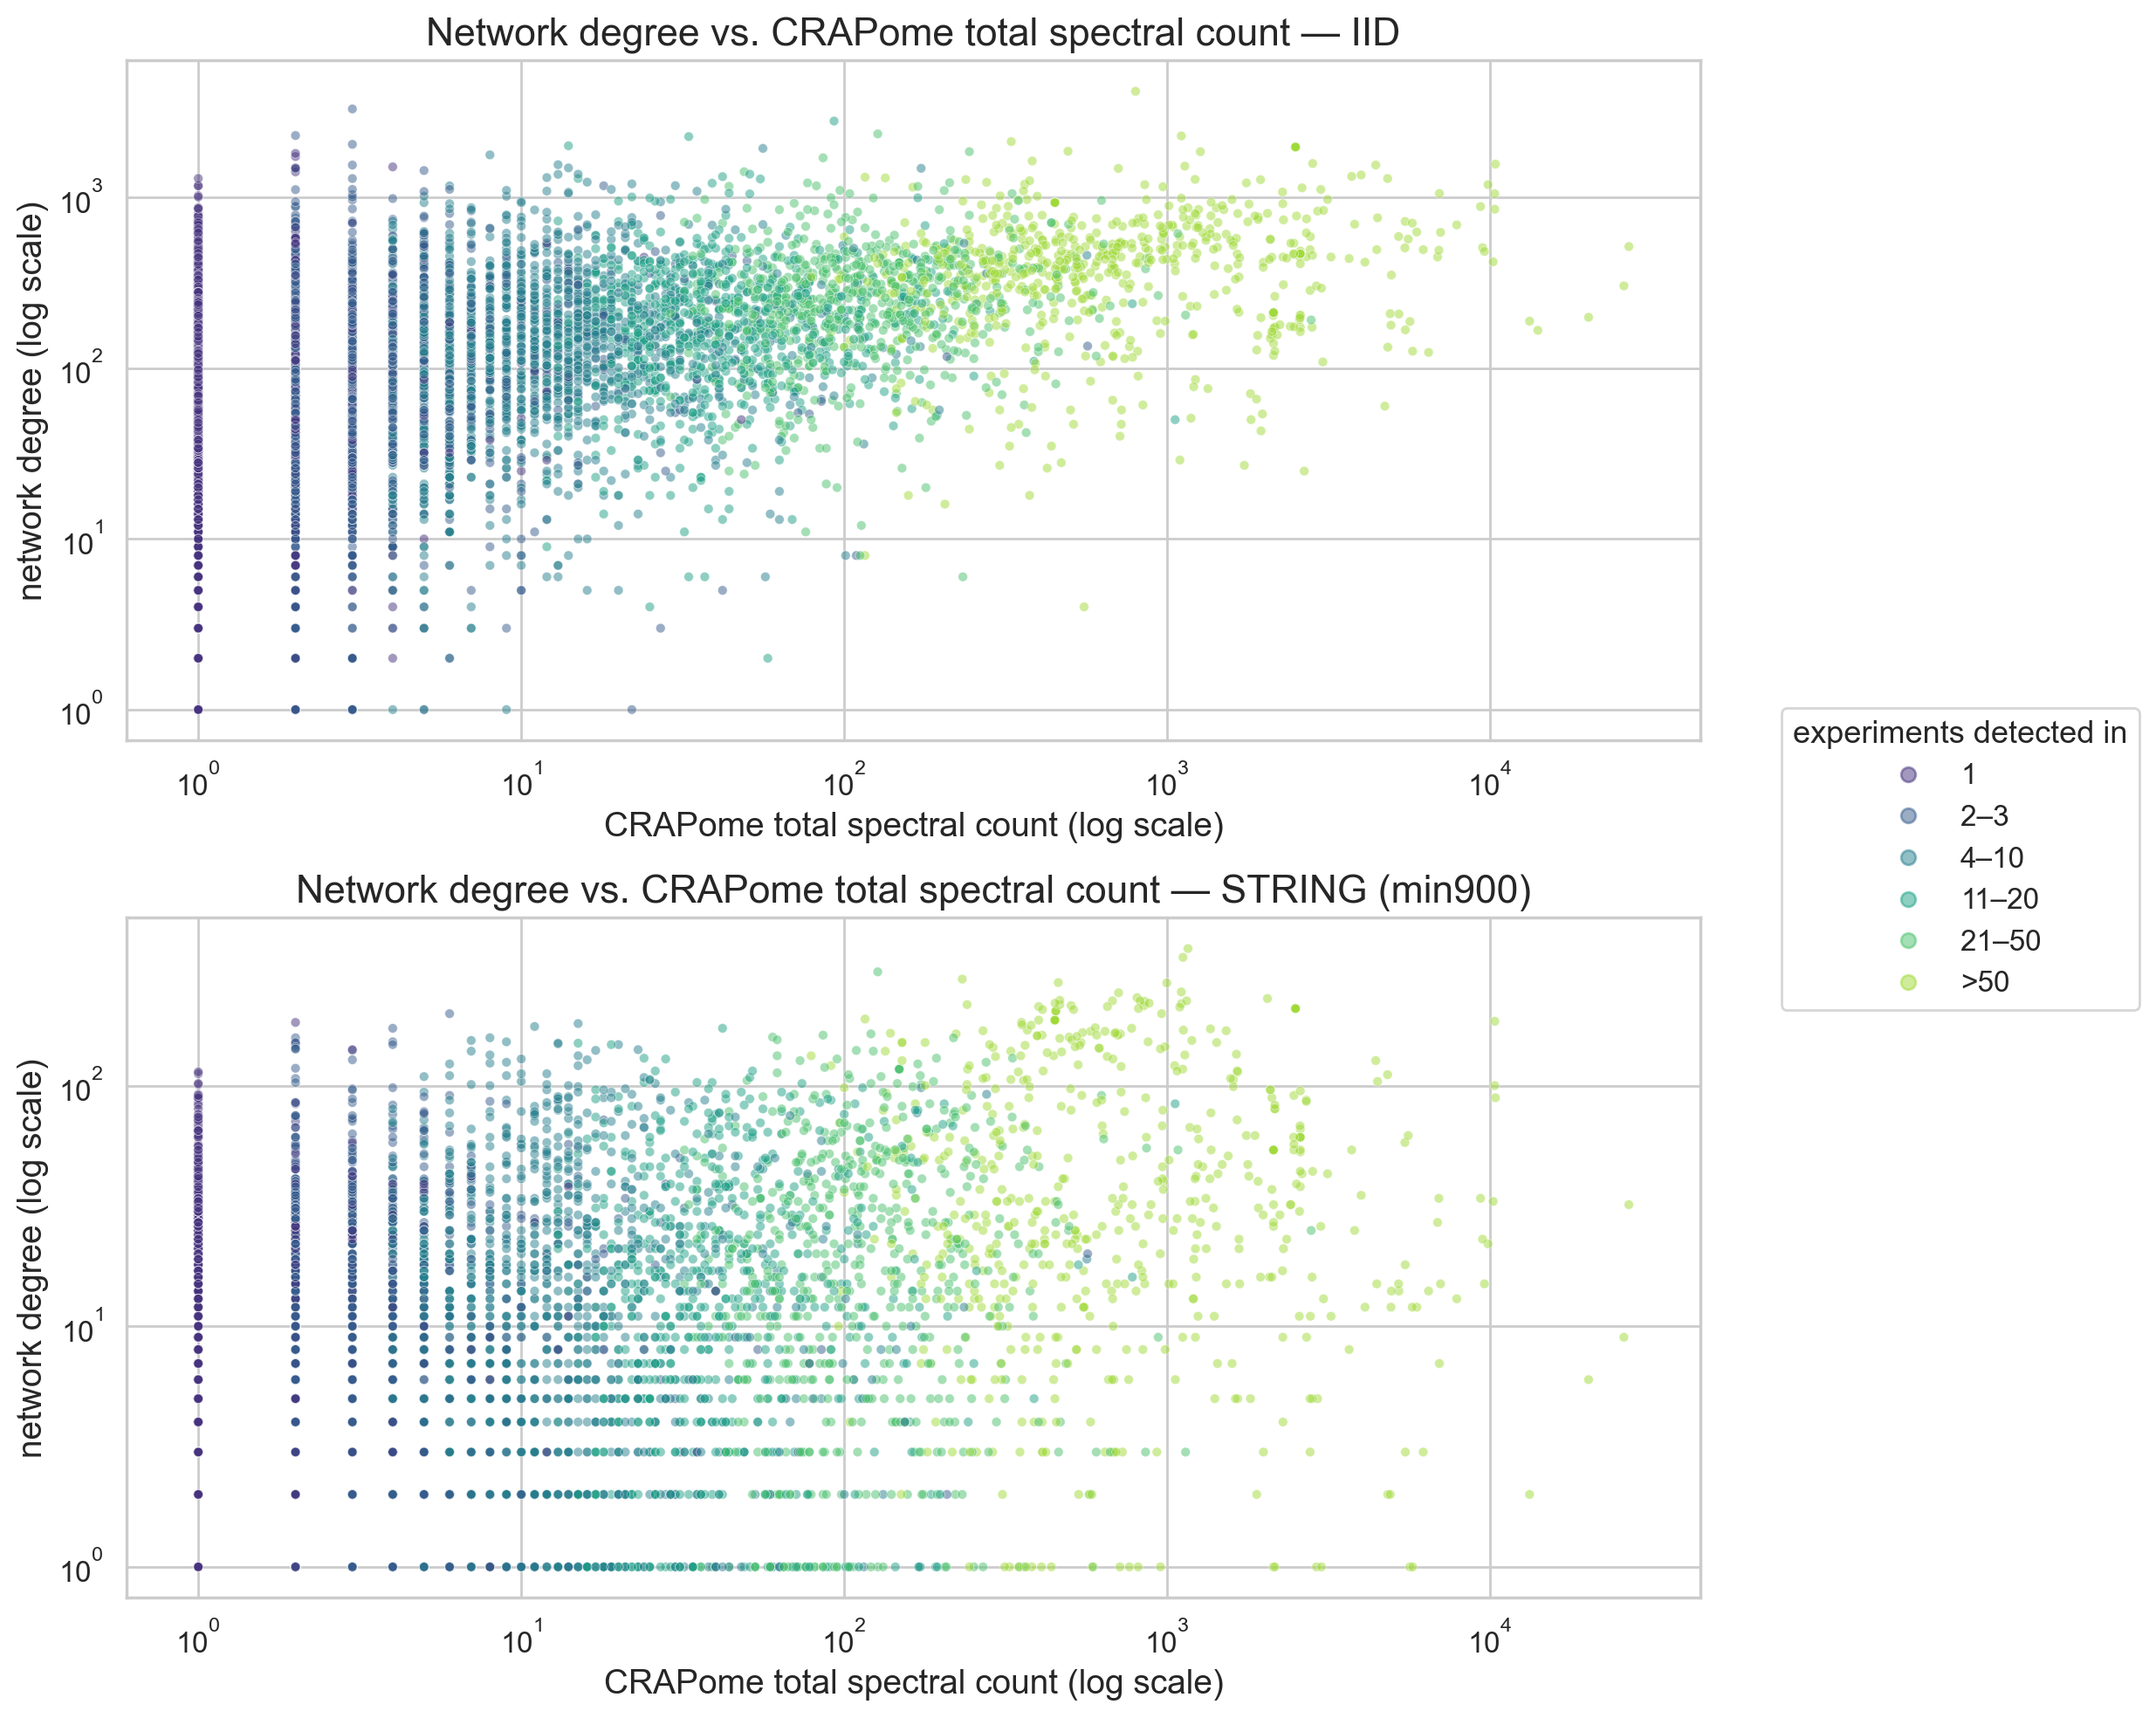

In [34]:
bin_edges = [0, 1, 3, 10, 20, 50, float("inf")]
bin_labels = ["1", "2–3", "4–10", "11–20", "21–50", ">50"]

in_crapome_any = {}
fig, axes = plt.subplots(len(NETWORKS), 1, figsize=(10, 5 * len(NETWORKS)), dpi=200)

for ax, (net_name, m) in zip(axes, merged.items()):
    ica = m[m["total_spectral_count"] > 0].copy()

    rho, rho_p = stats.spearmanr(ica["total_spectral_count"], ica["degree"])
    print(f"{net_name}: Spearman rho = {rho:.3f}, p = {rho_p:.3e}, n = {len(ica)}")

    ica["experiments_detected_bin"] = pd.cut(
        ica["n_experiments_detected"], bins=bin_edges, labels=bin_labels
    )
    in_crapome_any[net_name] = ica

    sns.scatterplot(
        data=ica,
        x="total_spectral_count",
        y="degree",
        hue="experiments_detected_bin",
        hue_order=bin_labels,
        palette="viridis",
        alpha=0.5,
        s=15,
        ax=ax,
        legend=False,
    )
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("CRAPome total spectral count (log scale)")
    ax.set_ylabel("network degree (log scale)")
    ax.set_title(f"Network degree vs. CRAPome total spectral count — {net_name}")

handles = [
    plt.Line2D([0], [0], marker="o", linestyle="", alpha=0.5,
               color=sns.color_palette("viridis", len(bin_labels))[i])
    for i in range(len(bin_labels))
]
fig.legend(
    handles, bin_labels,
    title="experiments detected in",
    bbox_to_anchor=(1.02, 0.5), loc="center left",
)

fig.tight_layout()
plt.show()

### Apply the spectral-count threshold

Now define "in CRAPome" membership as total spectral count > 5 — a minimal abundance threshold to exclude proteins that only turned up as a handful of spurious hits. Membership is defined once on the full CRAPome table (network-independent), then applied to each network's node set.

In [18]:
CRAPOME_SPECTRAL_COUNT_THRESHOLD = 5

crapome_detected = set(
    crapome_summary.loc[
        crapome_summary["total_spectral_count"] > CRAPOME_SPECTRAL_COUNT_THRESHOLD, "geneSymbol"
    ]
)

for net_name, m in merged.items():
    m["in_crapome"] = m["geneSymbol"].isin(crapome_detected)
    n_in = m["in_crapome"].sum()
    n_out = (~m["in_crapome"]).sum()
    print(f"--- {net_name} ---")
    print(f"Network nodes: {len(m)}")
    print(f"  in CRAPome (total spectral count > {CRAPOME_SPECTRAL_COUNT_THRESHOLD}): {n_in} ({n_in / len(m):.1%})")
    print(f"  not in CRAPome: {n_out} ({n_out / len(m):.1%})")

merged["IID"].head()

--- IID ---
Network nodes: 18427
  in CRAPome (total spectral count > 5): 3669 (19.9%)
  not in CRAPome: 14758 (80.1%)
--- STRING (min900) ---
Network nodes: 11995
  in CRAPome (total spectral count > 5): 3116 (26.0%)
  not in CRAPome: 8879 (74.0%)


,geneSymbol,degree,Uniprot ID,n_experiments_detected,experiment_frequency,total_spectral_count,in_crapome
0,FLNC,413,Q14315,90.0,0.262391,815.0,True
1,MAP2K4,455,P45985,2.0,0.005831,45.0,True
2,MAP4K2,200,NaN,0.0,0.000000,0.0,False
3,MAPK8IP3,149,Q9UPT6,1.0,0.002915,3.0,False
4,MAP3K11,659,NaN,0.0,0.000000,0.0,False


## Degree distribution: CRAPome vs. non-CRAPome proteins

In [19]:
for net_name, m in merged.items():
    print(f"--- {net_name} ---")
    display(m.groupby("in_crapome")["degree"].describe())

--- IID ---


,count,mean,std,min,25%,50%,75%,max
in_crapome,,,,,,,,
False,14758.0,100.87810,158.163610,1.0,18.0,52.0,125.0,3310.0
True,3669.0,272.74816,283.612595,1.0,100.0,192.0,352.0,4200.0


--- STRING (min900) ---


,count,mean,std,min,25%,50%,75%,max
in_crapome,,,,,,,,
False,8879.0,11.805271,18.402352,1.0,2.0,6.0,14.0,209.0
True,3116.0,30.895379,42.119778,1.0,5.0,15.0,38.0,371.0


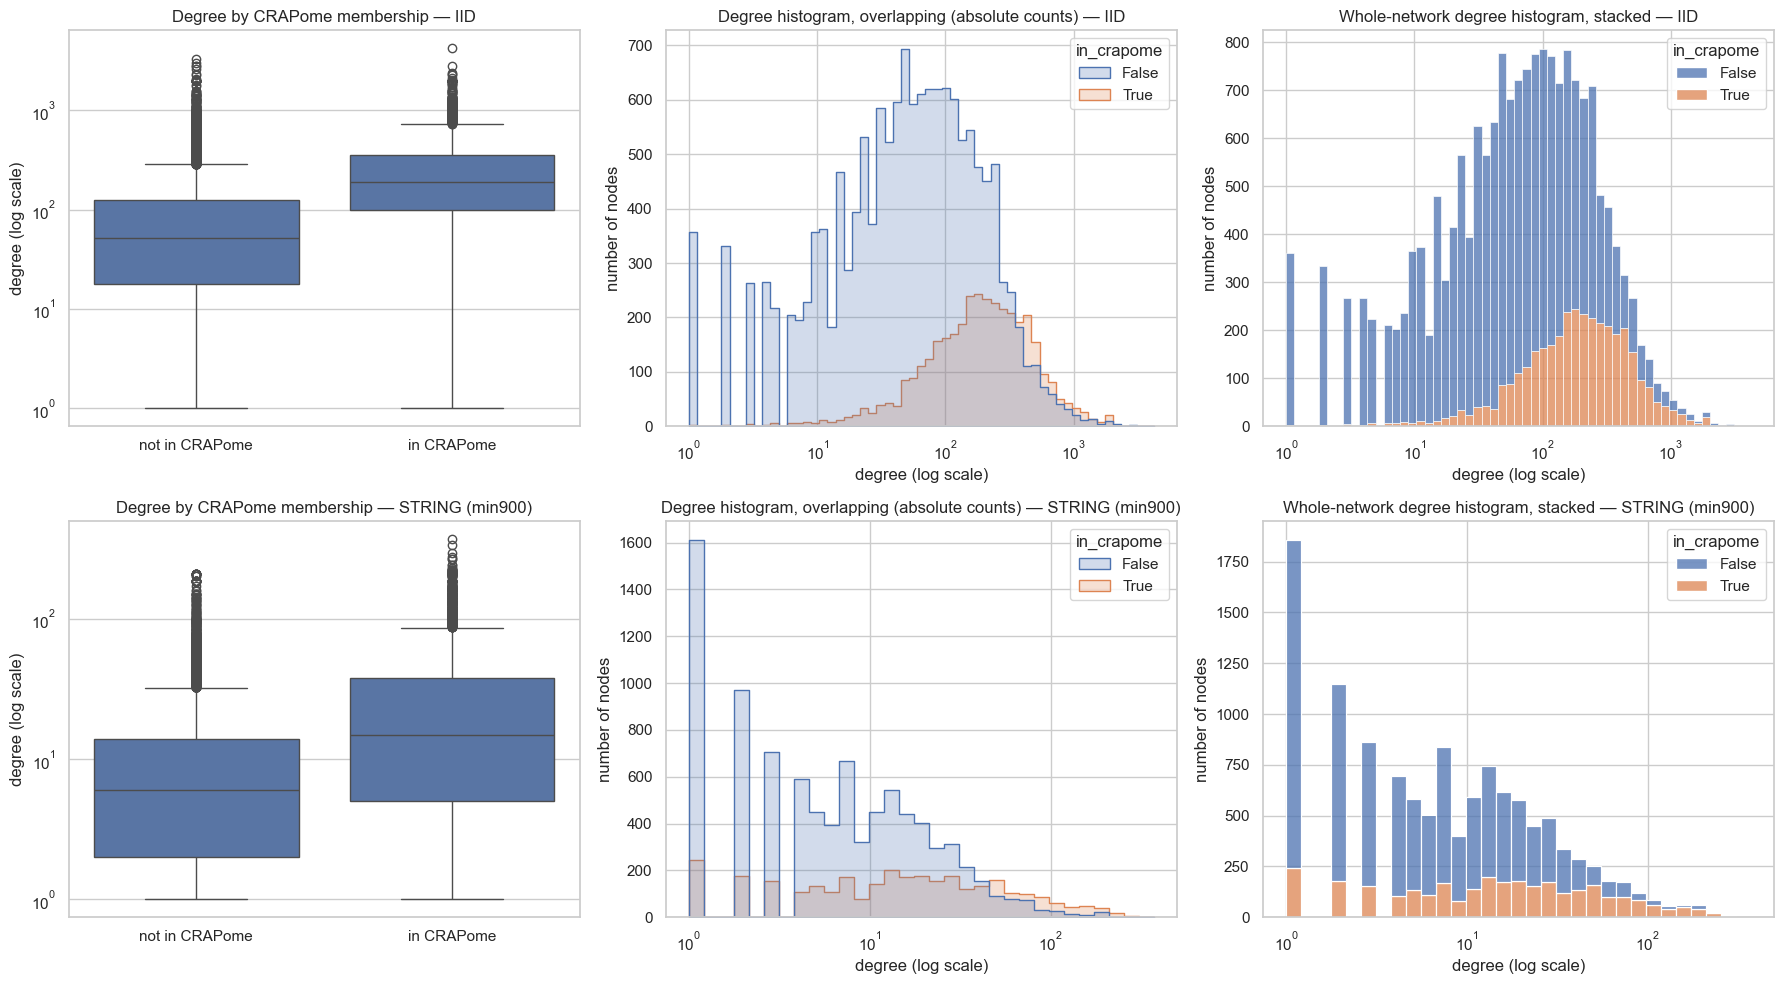

In [20]:
fig, axes = plt.subplots(len(merged), 3, figsize=(18, 5 * len(merged)))
if len(merged) == 1:
    axes = axes[np.newaxis, :]

for row, (net_name, m) in enumerate(merged.items()):
    ax0, ax1, ax2 = axes[row]

    sns.boxplot(data=m, x="in_crapome", y="degree", ax=ax0)
    ax0.set_yscale("log", base=10)
    ax0.set_xticks([0, 1])
    ax0.set_xticklabels(["not in CRAPome", "in CRAPome"])
    ax0.set_xlabel("")
    ax0.set_ylabel("degree (log scale)")
    ax0.set_title(f"Degree by CRAPome membership — {net_name}")

    sns.histplot(
        data=m,
        x="degree",
        hue="in_crapome",
        stat="count",
        common_norm=False,
        multiple="layer",
        bins='auto',
        log_scale=True,
        element="step",
        ax=ax1,
    )
    ax1.set_xlabel("degree (log scale)")
    ax1.set_ylabel("number of nodes")
    ax1.set_title(f"Degree histogram, overlapping (absolute counts) — {net_name}")

    sns.histplot(
        data=m,
        x="degree",
        hue="in_crapome",
        stat="count",
        multiple="stack",
        bins='auto',
        log_scale=True,
        ax=ax2,
    )
    ax2.set_xlabel("degree (log scale)")
    ax2.set_ylabel("number of nodes")
    ax2.set_title(f"Whole-network degree histogram, stacked — {net_name}")

fig.tight_layout()
plt.show()

### Statistical test

Mann-Whitney U test (non-parametric, appropriate for the heavy-tailed degree distribution) comparing degree of CRAPome-listed vs. non-listed network nodes, per network.

In [21]:
for net_name, m in merged.items():
    deg_in = m.loc[m["in_crapome"], "degree"]
    deg_out = m.loc[~m["in_crapome"], "degree"]

    u_stat, p_value = stats.mannwhitneyu(deg_in, deg_out, alternative="two-sided")
    print(f"--- {net_name} ---")
    print(f"median degree, in CRAPome:     {deg_in.median():.1f}")
    print(f"median degree, not in CRAPome: {deg_out.median():.1f}")
    print(f"Mann-Whitney U = {u_stat:.0f}, p = {p_value:.3e}")

--- IID ---
median degree, in CRAPome:     192.0
median degree, not in CRAPome: 52.0
Mann-Whitney U = 42845172, p = 0.000e+00
--- STRING (min900) ---
median degree, in CRAPome:     15.0
median degree, not in CRAPome: 6.0
Mann-Whitney U = 18895036, p = 1.423e-204


## Top hub proteins that are also frequent CRAPome contaminants

Candidates for edge/node filtering with CRAPome as described in `CLAUDE.md`: high-degree nodes that are also flagged as background binders in a large fraction of control experiments. Shown separately per network, since degree (and hence ranking) differs between them.

In [22]:
top_hub_contaminants = {}
for net_name, m in merged.items():
    print(f"--- {net_name} ---")
    top_hub_contaminants[net_name] = (
        m[m["in_crapome"]]
        .sort_values(["experiment_frequency", "degree"], ascending=False)
        .head(25)
        [["geneSymbol", "degree", "n_experiments_detected", "experiment_frequency", "total_spectral_count"]]
    )
    display(top_hub_contaminants[net_name])

--- IID ---


,geneSymbol,degree,n_experiments_detected,experiment_frequency,total_spectral_count
2653,HSPA8,1572,328.0,0.956268,10381.0
5433,HSPA1L,629,322.0,0.938776,5926.0
366,TUBA1A,887,321.0,0.935860,9337.0
1343,TUBA1C,484,321.0,0.935860,9600.0
4222,TUBA1B,421,321.0,0.935860,10216.0
9170,KRT1,304,320.0,0.932945,25949.0
3680,HSPA2,419,318.0,0.927114,4096.0
5503,TUBA3E,124,316.0,0.921283,6446.0
2460,TUBB,1192,314.0,0.915452,9850.0
9304,HSPA6,440,313.0,0.912536,3659.0


--- STRING (min900) ---


,geneSymbol,degree,n_experiments_detected,experiment_frequency,total_spectral_count
384,HSPA8,89,328.0,0.956268,10381.0
363,HSPA1L,12,322.0,0.938776,5926.0
1054,TUBA1A,34,321.0,0.935860,9337.0
466,TUBA1B,33,321.0,0.935860,10216.0
2114,TUBA1C,15,321.0,0.935860,9600.0
8264,KRT1,9,320.0,0.932945,25949.0
564,HSPA2,12,318.0,0.927114,4096.0
1960,TUBA3E,14,316.0,0.921283,6446.0
2122,TUBB,22,314.0,0.915452,9850.0
690,HSPA6,8,313.0,0.912536,3659.0


## Tissue-specific filtering: networks restricted to Brain - Hippocampus

Run `diseasemodulediscovery/bin/tissue_specific_filtering.py` to remove nodes not expressed in the brain hippocampus (GTEx, TPM threshold = 2) from each network, then repeat the CRAPome degree-distribution comparison on the filtered networks. Since tissue filtering removes low-degree, less-connected proteins disproportionately (unexpressed genes tend to be less studied), we'd expect the CRAPome-vs-network gap to narrow somewhat, though CRAPome contaminants (housekeeping proteins like actin, tubulin, HSPs) are usually ubiquitously expressed and should mostly survive the filter.

GTEx expression data is read from the locally cached `data/expression_by_tissue.gct` (median TPM per gene per tissue, GTEx v11) rather than re-downloaded, and passed to the script via `--custom_expression_file`. The networks' node names are gene symbols, so `--id_space symbol` is used; the script maps the GTEx Ensembl IDs to HGNC symbols via g:Profiler internally.

In [23]:
import os
import subprocess
import sys

TISSUE = "Brain_Hippocampus"
THRESHOLD = 2
FILTERING_BIN_DIR = "/Users/motan/Uni/ba/diseasemodulediscovery/bin"
FILTERING_SCRIPT = f"{FILTERING_BIN_DIR}/tissue_specific_filtering.py"
GTEX_GCT_PATH = "data/expression_by_tissue.gct"

NETWORK_SLUGS = {"IID": "iid", "STRING (min900)": "string_min900"}
FILTERING_OUTDIRS = {
    net_name: f"/Users/motan/Uni/ba/data/tissue_filtering/{slug}_brain_hippocampus"
    for net_name, slug in NETWORK_SLUGS.items()
}

# Build a --custom_expression_file: columns 'id' (versionless Ensembl gene id)
# and the tissue column, mirroring what the script's own GTEx download branch produces.
gtex = pd.read_csv(GTEX_GCT_PATH, sep="\t", skiprows=2, header=0)
gtex = gtex.rename(columns={gtex.columns[0]: "id"})
gtex["id"] = gtex["id"].apply(lambda x: x.split(".")[0])

filtered_network_paths = {}
filtering_stats_rows = []

for net_name, net_path in NETWORKS.items():
    outdir = FILTERING_OUTDIRS[net_name]
    os.makedirs(outdir, exist_ok=True)

    custom_expression_path = f"{outdir}/gtex_expression_custom.tsv"
    gtex[["id", TISSUE]].to_csv(custom_expression_path, sep="\t", index=False)

    net_stem = Path(net_path).stem
    filtered_network_path = f"{outdir}/{net_stem}.{TISSUE}.null.{THRESHOLD}.gt"
    filtered_network_paths[net_name] = filtered_network_path

    print(f"--- {net_name} ---")
    if Path(filtered_network_path).exists():
        print("[skip] filtered network already exists")
    else:
        result = subprocess.run(
            [
                sys.executable, FILTERING_SCRIPT,
                "--network", str(net_path),
                "--tissue", TISSUE,
                "--threshold", str(THRESHOLD),
                "--filtering_source", "null",
                "--custom_expression_file", custom_expression_path,
                "--id_space", "symbol",
            ],
            cwd=outdir,
            env={**os.environ, "PYTHONPATH": FILTERING_BIN_DIR},
            capture_output=True,
            text=True,
        )
        print(result.stdout)
        if result.returncode != 0:
            print(result.stderr)
            raise RuntimeError(f"tissue_specific_filtering.py failed for {net_name}")

    stat_row = pd.read_csv(f"{outdir}/filtering_statistic.tsv", sep="\t").iloc[0].to_dict()
    stat_row["network_name"] = net_name
    filtering_stats_rows.append(stat_row)

filtering_stats_df = pd.DataFrame(filtering_stats_rows)
filtering_stats_df

--- IID ---
[skip] filtered network already exists
--- STRING (min900) ---
[skip] filtered network already exists


,network,tissue,genes_in_tissue,genes_not_in_network_absolute,genes_not_in_network_relative,genes_not_in_expression_file_absolute,genes_not_in_expression_file_relative,genes_filtered_by_threshold_absolute,genes_filtered_by_threshold_relative,network_name
0,iid.human.Symbol.Brain_Hippocampus.null.2,Brain_Hippocampus,11865,21143,0.537908,166,0.009057,6911,0.377053,IID
1,string.human_links_v12_0_min900.Symbol.Brain_H...,Brain_Hippocampus,11865,27477,0.699054,98,0.008217,3881,0.325396,STRING (min900)


In [24]:
merged_filtered = {}
for net_name in NETWORKS:
    g_filtered, degree_df_filtered = load_degree_df(filtered_network_paths[net_name])
    m_f = merge_with_crapome(degree_df_filtered)
    m_f["in_crapome"] = m_f["geneSymbol"].isin(crapome_detected)
    merged_filtered[net_name] = m_f

    n_in_f = m_f["in_crapome"].sum()
    n_out_f = (~m_f["in_crapome"]).sum()
    print(f"--- {net_name} ---")
    print(g_filtered)
    print(f"Filtered network nodes: {len(m_f)} (full network: {len(merged[net_name])})")
    print(f"  in CRAPome: {n_in_f} ({n_in_f / len(m_f):.1%})")
    print(f"  not in CRAPome: {n_out_f} ({n_out_f / len(m_f):.1%})")
    display(m_f.groupby("in_crapome")["degree"].describe())

--- IID ---
<Graph object, undirected, with 11252 vertices and 699621 edges, 2 internal vertex properties, at 0x3333310f0>
Filtered network nodes: 11288 (full network: 18427)
  in CRAPome: 3041 (26.9%)
  not in CRAPome: 8247 (73.1%)


,count,mean,std,min,25%,50%,75%,max
in_crapome,,,,,,,,
False,8247.0,85.884079,127.752115,0.0,18.0,45.0,105.0,2683.0
True,3041.0,229.080237,219.955096,0.0,90.0,169.0,301.0,3565.0


--- STRING (min900) ---
<Graph object, undirected, with 7948 vertices and 61038 edges, 2 internal vertex properties, at 0x30c2e7890>
Filtered network nodes: 7972 (full network: 11995)
  in CRAPome: 2646 (33.2%)
  not in CRAPome: 5326 (66.8%)


,count,mean,std,min,25%,50%,75%,max
in_crapome,,,,,,,,
False,5326.0,9.768682,14.149351,0.0,2.0,5.0,12.0,147.0
True,2646.0,26.682162,36.526178,0.0,4.0,13.0,31.0,300.0


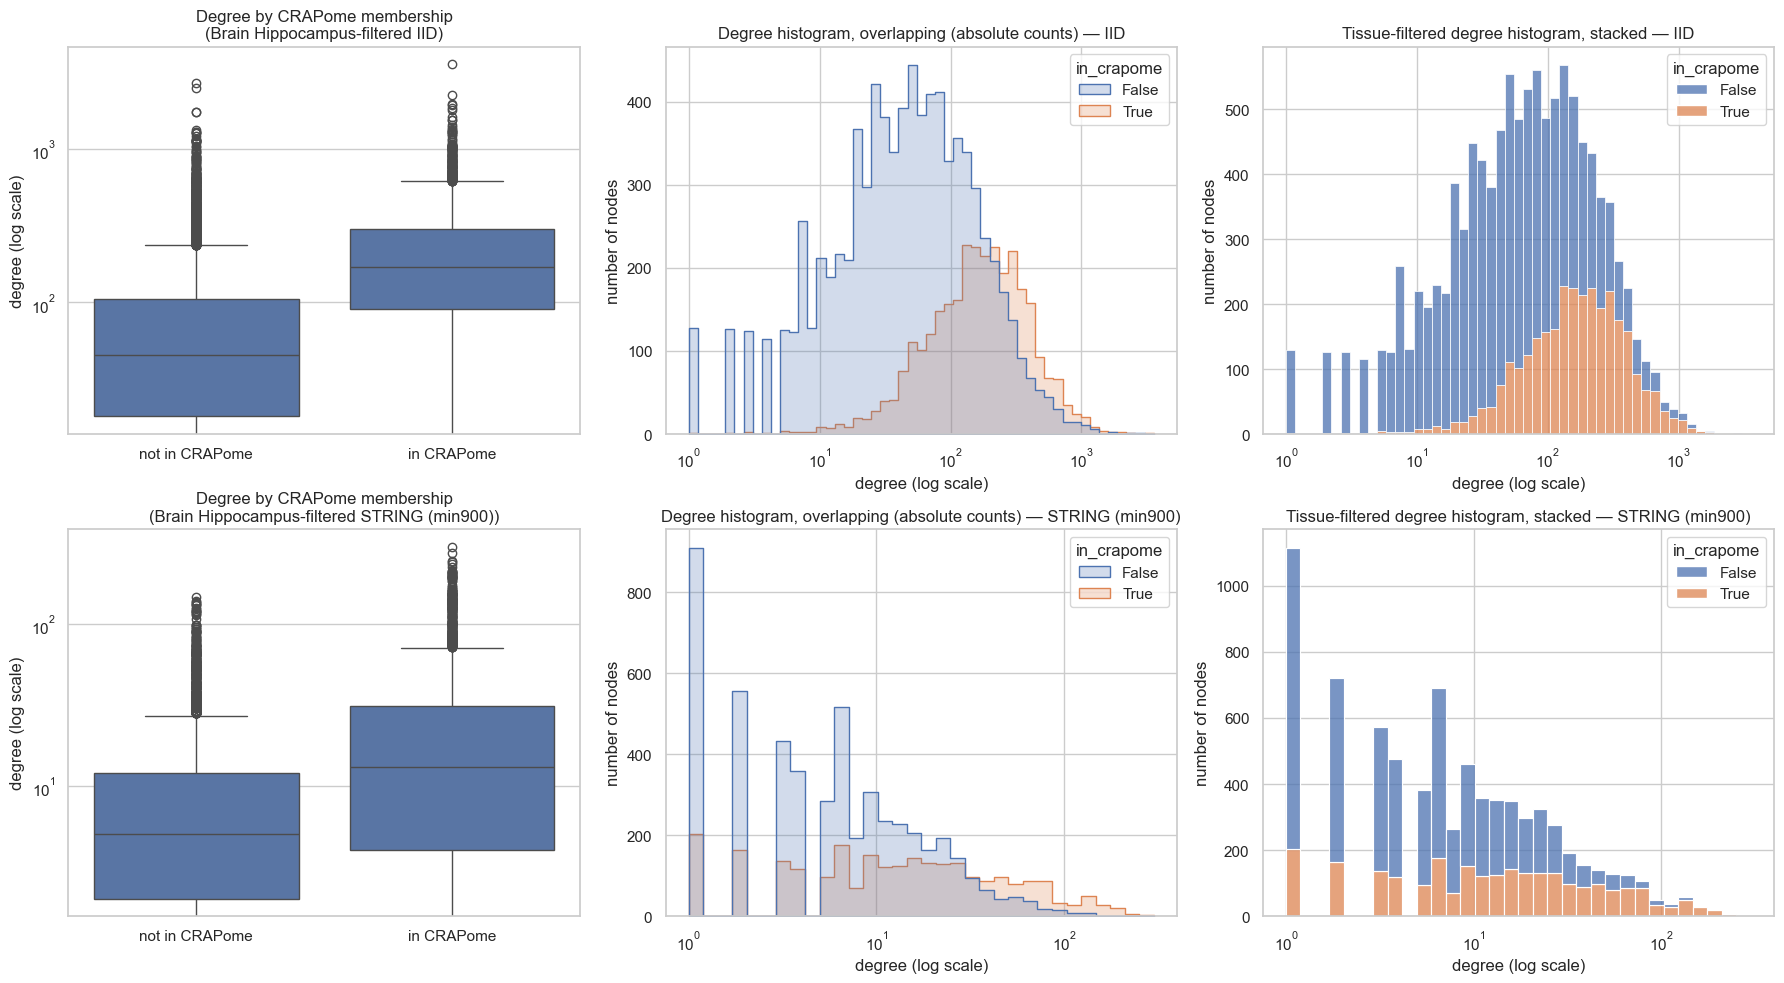

--- IID ---
median degree, in CRAPome:     169.0
median degree, not in CRAPome: 45.0
Mann-Whitney U = 20128112, p = 0.000e+00
--- STRING (min900) ---
median degree, in CRAPome:     13.0
median degree, not in CRAPome: 5.0
Mann-Whitney U = 9656488, p = 5.578e-161


In [25]:
fig, axes = plt.subplots(len(merged_filtered), 3, figsize=(18, 5 * len(merged_filtered)))
if len(merged_filtered) == 1:
    axes = axes[np.newaxis, :]

for row, (net_name, m_f) in enumerate(merged_filtered.items()):
    ax0, ax1, ax2 = axes[row]

    sns.boxplot(data=m_f, x="in_crapome", y="degree", ax=ax0)
    ax0.set_yscale("log", base=10)
    ax0.set_xticks([0, 1])
    ax0.set_xticklabels(["not in CRAPome", "in CRAPome"])
    ax0.set_xlabel("")
    ax0.set_ylabel("degree (log scale)")
    ax0.set_title(f"Degree by CRAPome membership\n(Brain Hippocampus-filtered {net_name})")

    sns.histplot(
        data=m_f,
        x="degree",
        hue="in_crapome",
        stat="count",
        common_norm=False,
        multiple="layer",
        bins='auto',
        log_scale=True,
        element="step",
        ax=ax1,
    )
    ax1.set_xlabel("degree (log scale)")
    ax1.set_ylabel("number of nodes")
    ax1.set_title(f"Degree histogram, overlapping (absolute counts) — {net_name}")

    sns.histplot(
        data=m_f,
        x="degree",
        hue="in_crapome",
        stat="count",
        multiple="stack",
        bins='auto',
        log_scale=True,
        ax=ax2,
    )
    ax2.set_xlabel("degree (log scale)")
    ax2.set_ylabel("number of nodes")
    ax2.set_title(f"Tissue-filtered degree histogram, stacked — {net_name}")

fig.tight_layout()
plt.show()

for net_name, m_f in merged_filtered.items():
    deg_in_f = m_f.loc[m_f["in_crapome"], "degree"]
    deg_out_f = m_f.loc[~m_f["in_crapome"], "degree"]
    u_stat_f, p_value_f = stats.mannwhitneyu(deg_in_f, deg_out_f, alternative="two-sided")
    print(f"--- {net_name} ---")
    print(f"median degree, in CRAPome:     {deg_in_f.median():.1f}")
    print(f"median degree, not in CRAPome: {deg_out_f.median():.1f}")
    print(f"Mann-Whitney U = {u_stat_f:.0f}, p = {p_value_f:.3e}")